# Environment Setup (Run Once)
This cell installs only missing packages to keep re-runs fast during the hackathon.

In [ ]:
# Install only missing packages (fast re-runs)
import importlib.util
import subprocess
import sys

# pip package name -> import module name
package_module_pairs = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("geopandas", "geopandas"),
    ("rasterio", "rasterio"),
    ("shapely", "shapely"),
    ("pyproj", "pyproj"),
    ("fiona", "fiona"),
    ("scipy", "scipy"),
    ("scikit-learn", "sklearn"),
    ("matplotlib", "matplotlib"),
    ("joblib", "joblib"),
    ("localtileserver", "localtileserver"),
    ("folium", "folium"),
    ("flask", "flask"),
]

def is_installed(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None

missing = [
    pip_name
    for pip_name, module_name in package_module_pairs
    if not is_installed(module_name)
]
print("Missing packages:", missing)

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *missing])
else:
    print("All required packages are already installed.")

Missing packages: ['scikit-learn']


# Environment Setup (Run Once)
Install required dependencies to avoid missing-package errors during the demo.

In [2]:
# Install core GIS + ML dependencies (run once)
import sys
import subprocess

packages = [
    "numpy",
    "pandas",
    "geopandas",
    "rasterio",
    "shapely",
    "pyproj",
    "fiona",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "joblib",
    "localtileserver",
    "folium",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *packages])

0

# GeoShield AI - Phase 2: Preprocessing + Feature Engineering

This notebook focuses on loading the raw GIS datasets, validating CRS, and preparing aligned raster layers for ML-ready feature extraction.

## 1) Setup and Paths
Update paths if your dataset folder changes.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

# Base project paths: keep all generated artifacts inside backend/
PROJECT_ROOT = Path(r"D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend")
DATASET_ROOT = PROJECT_ROOT / "data" / "Sindhupalchowk_Dataset_Landslide"

RAW_RASTER_DIR = PROJECT_ROOT / "data" / "raw" / "raster"
RAW_VECTOR_DIR = PROJECT_ROOT / "data" / "raw" / "vector"
RAW_INVENTORY_DIR = PROJECT_ROOT / "data" / "raw" / "inventory"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "data" / "outputs"

for p in [RAW_RASTER_DIR, RAW_VECTOR_DIR, RAW_INVENTORY_DIR, PROCESSED_DIR, OUTPUTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_ROOT

WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide')

## 2) Define Dataset File Paths
Map the raw dataset files to a consistent set of names. Update any paths that differ in your folder.

In [4]:
# Raster layers (updated to match your current file names)
raster_paths = {
    "dem": DATASET_ROOT / "DEM" / "Sindhupalchok_DEM.tif",
    "slope": DATASET_ROOT / "Slope" / "Sindhupalchok_Slope.tif",
    "aspect": DATASET_ROOT / "Aspect" / "Sindhupalchok_Aspect.tif",
    "twi": DATASET_ROOT / "TWI" / "Sindhupalchok_TWI_2025.tif",
    # Rainfall raster now available
    "rainfall": DATASET_ROOT / "Rainfall" / "Sindhupalchok_Rainfall_2015_2025.tif",
    "ndvi": DATASET_ROOT / "NDVI" / "Sindhupalchok_NDVI_2025_30m.tif",
    "landcover": DATASET_ROOT / "LULC" / "Sindhupalchok_LULC_30m.tif",
    "river_proximity": DATASET_ROOT / "RiverProximity" / "Sindhupalchok_RiverProximity.tif",
}

# Vector layers
vector_paths = {
    "boundary": DATASET_ROOT / "Road and River Networks with Sindhupalchowk Boundary (shapefiles and gdb)" / "processed_data" / "sindhupalchok_boundary_utm.shp",
    "roads": DATASET_ROOT / "Road and River Networks with Sindhupalchowk Boundary (shapefiles and gdb)" / "processed_data" / "roads_sindhupalchok.shp",
    "rivers": DATASET_ROOT / "Road and River Networks with Sindhupalchowk Boundary (shapefiles and gdb)" / "processed_data" / "rivers_sindhupalchok.shp",
}

# Landslide inventory (CSV with lat/lon)
inventory_path = DATASET_ROOT / "Landslide_Inventory_Datasets" / "sindhupalchowk_landslides.csv"

# Optional rainfall CSVs (used only if raster is missing and CSV has lat/lon/value)
rainfall_csv_paths = [
    DATASET_ROOT / "Rainfall" / "GeoShield_Rainfall_Timeline_2015_2025.csv",
    DATASET_ROOT / "Rainfall" / "Sindhupalchok_CHIRPS_2020.csv",
]

raster_paths, vector_paths, inventory_path, rainfall_csv_paths

({'dem': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/DEM/Sindhupalchok_DEM.tif'),
  'slope': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/Slope/Sindhupalchok_Slope.tif'),
  'aspect': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/Aspect/Sindhupalchok_Aspect.tif'),
  'twi': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/TWI/Sindhupalchok_TWI_2025.tif'),
  'rainfall': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/Rainfall/Sindhupalchok_Rainfall_2015_2025.tif'),
  'ndvi': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/NDVI/Sindhupalchok_NDVI_2025_30m.tif'),
  'landcover': WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/

In [5]:
# Convert rainfall CSV(s) to a raster using DEM grid (only if raster is missing)
from typing import List, Tuple
from scipy.interpolate import griddata

def detect_columns(df: pd.DataFrame) -> Tuple[str, str, str]:
    lower = {c.lower(): c for c in df.columns}
    lat_col = next((lower[c] for c in lower if "lat" in c), None)
    lon_col = next((lower[c] for c in lower if "lon" in c or "long" in c), None)
    val_col = next((lower[c] for c in lower if "rain" in c or "precip" in c or "chirps" in c), None)
    if not (lat_col and lon_col and val_col):
        raise ValueError(f"Could not detect columns. Available: {list(df.columns)}")
    return lat_col, lon_col, val_col

def rainfall_csv_to_raster(csv_paths: List[Path], ref_raster: Path, out_path: Path) -> Path:
    dfs = []
    for p in csv_paths:
        if p.exists():
            dfs.append(pd.read_csv(p))
    if not dfs:
        raise FileNotFoundError("No rainfall CSV files found.")
    df = pd.concat(dfs, ignore_index=True)
    lat_col, lon_col, val_col = detect_columns(df)
    df = df[[lat_col, lon_col, val_col]].dropna()

    with rasterio.open(ref_raster) as ref:
        transform = ref.transform
        width, height = ref.width, ref.height
        crs = ref.crs
        # Build grid of pixel centers
        xs = np.arange(width) + 0.5
        ys = np.arange(height) + 0.5
        xs, ys = np.meshgrid(xs, ys)
        lon, lat = rasterio.transform.xy(transform, ys, xs)
        lon = np.array(lon)
        lat = np.array(lat)

    points = np.column_stack([df[lon_col].values, df[lat_col].values])
    values = df[val_col].values.astype("float32")

    # Nearest interpolation fills gaps and keeps it fast for hackathon demos
    grid = griddata(points, values, (lon, lat), method="nearest")
    grid = grid.astype("float32")

    out_meta = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "float32",
        "crs": crs,
        "transform": transform,
        "nodata": None,
    }
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **out_meta) as dst:
        dst.write(grid, 1)

    print("Rainfall raster created:", out_path)
    return out_path

# Build rainfall raster only if missing
if not raster_paths["rainfall"].exists():
    raster_paths["rainfall"] = rainfall_csv_to_raster(
        rainfall_csv_paths,
        raster_paths["dem"],
        PROJECT_ROOT / "data" / "raw" / "raster" / "rainfall_from_csv.tif",
    )
else:
    print("Rainfall raster found:", raster_paths["rainfall"])

raster_paths["rainfall"]

Rainfall raster found: D:\Side_Projects\ai-ml\GeoShield_Ecothon\backend\data\Sindhupalchowk_Dataset_Landslide\Rainfall\Sindhupalchok_Rainfall_2015_2025.tif


WindowsPath('D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/Sindhupalchowk_Dataset_Landslide/Rainfall/Sindhupalchok_Rainfall_2015_2025.tif')

## 3) Load Raster Metadata
Print CRS, resolution, bounds, and shape for each raster layer.

In [6]:
def read_raster_info(path: Path):
    if not path.exists():
        return {"path": str(path), "exists": False}
    with rasterio.open(path) as src:
        return {
            "path": str(path),
            "exists": True,
            "crs": src.crs.to_string() if src.crs else None,
            "resolution": src.res,
            "shape": (src.height, src.width),
            "bounds": src.bounds,
            "nodata": src.nodata,
        }

raster_meta = {name: read_raster_info(path) for name, path in raster_paths.items()}
pd.DataFrame(raster_meta).T

,path,exists,crs,resolution,shape,bounds,nodata
dem,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.0002694945852358564, 0.0002694945852358564)","(2167, 2313)","(85.44178677419069, 27.61201014065843, 86.0651...",None
slope,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.0002694945852358564, 0.0002694945852358564)","(2167, 2313)","(85.44178677419069, 27.61201014065843, 86.0651...",None
aspect,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.0002694945852358564, 0.0002694945852358564)","(2167, 2313)","(85.44178677419069, 27.61201014065843, 86.0651...",None
twi,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.00026949458523585647, 0.00026949458523585647)","(2168, 2314)","(85.44164128151688, 27.611876214095382, 86.065...",None
rainfall,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.00026949458523585647, 0.00026949458523585647)","(2168, 2314)","(85.44164128151688, 27.611876214095382, 86.065...",None
ndvi,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.00026949458523585647, 0.00026949458523585647)","(2168, 2314)","(85.44164128151688, 27.611876214095382, 86.065...",None
landcover,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:4326,"(0.00026949458523585647, 0.00026949458523585647)","(2167, 2314)","(85.44165616849443, 27.61203096359034, 86.0652...",None
river_proximity,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,False,NaN,NaN,NaN,NaN,NaN


## 4) Load Vector Metadata
Inspect CRS and feature counts for boundary, roads, and rivers.

In [7]:
def read_vector_info(path: Path):
    if not path.exists():
        return {"path": str(path), "exists": False}
    gdf = gpd.read_file(path)
    return {
        "path": str(path),
        "exists": True,
        "crs": gdf.crs.to_string() if gdf.crs else None,
        "features": len(gdf),
        "bounds": gdf.total_bounds
    }

vector_meta = {name: read_vector_info(path) for name, path in vector_paths.items()}
pd.DataFrame(vector_meta).T

,path,exists,crs,features,bounds
boundary,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:32645,1,"[346881.6440516697, 3054544.906295163, 407973...."
roads,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,False,NaN,NaN,NaN
rivers,D:\Side_Projects\ai-ml\GeoShield_Ecothon\backe...,True,EPSG:32645,380,"[348985.69745377847, 3055005.6759925233, 40470..."


## 5) Load Landslide Inventory
Verify columns, missing values, and basic stats.

In [8]:
if inventory_path.exists():
    inventory_df = pd.read_csv(inventory_path)
    display(inventory_df.head())
    display(inventory_df.isna().sum())
else:
    inventory_df = pd.DataFrame()
    print("Inventory file not found. Check inventory_path.")

inventory_df.shape

,OID_,Name,FolderPath,SymbolID,AltMode,Base,Clamped,Extruded,Snippet,PopupInfo,Shape_Leng,Shape_Area,district,longitude,latitude
0,0,5/3/015,Sindhupalchowk.kmz/Sindhupalchowk/5/3,0,0,0.0,-1,0,NaN,NaN,0.004229,6.892264e-07,Sindhupalchowk,85.869635,27.756580
1,0,5/3/015,Sindhupalchowk.kmz/Sindhupalchowk/5/3,0,0,0.0,-1,0,NaN,NaN,0.003036,1.996351e-07,Sindhupalchowk,85.741945,27.863816
2,0,5/4/15,Sindhupalchowk.kmz/Sindhupalchowk/5/4,0,0,0.0,-1,0,NaN,NaN,0.002178,8.481171e-08,Sindhupalchowk,85.887642,27.862568
3,0,5/3/015,Sindhupalchowk.kmz/Sindhupalchowk/5/3,0,0,0.0,-1,0,NaN,NaN,0.003916,5.009103e-07,Sindhupalchowk,85.737043,27.863017
4,0,5/3/015,Sindhupalchowk.kmz/Sindhupalchowk/5/3,0,0,0.0,-1,0,NaN,NaN,0.005587,5.365643e-07,Sindhupalchowk,85.736675,27.898708


OID_             0
Name             0
FolderPath       0
SymbolID         0
AltMode          0
Base             0
Clamped          0
Extruded         0
Snippet       1434
PopupInfo     1434
Shape_Leng       0
Shape_Area       0
district         0
longitude        0
latitude         0
dtype: int64

(1434, 15)

## 6) CRS Validation (Target: EPSG:4326)
We will reproject any raster or vector that is not in EPSG:4326 in the next step.

In [9]:
TARGET_CRS = "EPSG:4326"

def needs_reprojection(crs_str: str | None):
    if not crs_str:
        return True
    return crs_str.upper() != TARGET_CRS

raster_reproject_flags = {name: needs_reprojection(meta.get("crs")) for name, meta in raster_meta.items()}
vector_reproject_flags = {name: needs_reprojection(meta.get("crs")) for name, meta in vector_meta.items()}

pd.DataFrame({"raster": raster_reproject_flags, "vector": vector_reproject_flags})

,raster,vector
dem,False,NaN
slope,False,NaN
aspect,False,NaN
twi,False,NaN
rainfall,False,NaN
ndvi,False,NaN
landcover,False,NaN
river_proximity,True,NaN
boundary,NaN,True
roads,NaN,True


## Next Steps
- Reproject to EPSG:4326 (if needed)
- Clip all datasets to the district boundary
- Create distance rasters for roads and rivers
- Align rasters to the same grid
- Stack rasters for ML feature extraction

## Phase 2 Pipeline (Step-by-Step)
We will implement the pipeline in modular steps. Each step saves outputs to `data/processed/` or `data/outputs/` and prints validation checks (CRS, dimensions, bounds, and missing values).

In [10]:
# Additional imports for geospatial processing and ML
import shutil
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
from rasterio import features
from rasterio.enums import Resampling
from rasterio.mask import mask
from rasterio.transform import Affine
from rasterio.warp import calculate_default_transform, reproject
from shapely.geometry import Point
from scipy.ndimage import distance_transform_edt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

# Subfolders for processed outputs
PROCESSED_RASTER_DIR = PROCESSED_DIR / "rasters"
PROCESSED_VECTOR_DIR = PROCESSED_DIR / "vectors"
PROCESSED_INVENTORY_DIR = PROCESSED_DIR / "inventory"
OUTPUT_FIG_DIR = OUTPUTS_DIR / "figures"

for p in [PROCESSED_RASTER_DIR, PROCESSED_VECTOR_DIR, PROCESSED_INVENTORY_DIR, OUTPUT_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Helper functions
# ----------------------------
def print_raster_info(path: Path, label: str) -> Dict:
    """Print and return basic raster metadata and missing-value stats."""
    info = {"label": label, "path": str(path), "exists": path.exists()}
    if not path.exists():
        print(info)
        return info
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        nodata_count = int(np.ma.count_masked(data))
        nan_count = int(np.isnan(data.filled(np.nan)).sum())
        info.update({
            "crs": src.crs.to_string() if src.crs else None,
            "resolution": src.res,
            "shape": (src.height, src.width),
            "bounds": src.bounds,
            "nodata": src.nodata,
            "nodata_count": nodata_count,
            "nan_count": nan_count,
        })
    print(info)
    return info

def print_vector_info(path: Path, label: str) -> Dict:
    """Print and return basic vector metadata."""
    info = {"label": label, "path": str(path), "exists": path.exists()}
    if not path.exists():
        print(info)
        return info
    gdf = gpd.read_file(path)
    info.update({
        "crs": gdf.crs.to_string() if gdf.crs else None,
        "features": len(gdf),
        "bounds": gdf.total_bounds.tolist(),
    })
    print(info)
    return info

def reproject_raster(in_path: Path, out_path: Path, target_crs: str) -> Path:
    """Reproject a raster to the target CRS. Copies if already in target."""
    if not in_path.exists():
        raise FileNotFoundError(in_path)
    with rasterio.open(in_path) as src:
        src_crs = src.crs.to_string() if src.crs else None
        if src_crs and src_crs.upper() == target_crs.upper():
            out_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copyfile(in_path, out_path)
            return out_path
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height,
        })
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.bilinear,
                )
    return out_path

def reproject_vector(in_path: Path, out_path: Path, target_crs: str) -> Path:
    """Reproject a vector layer to the target CRS."""
    if not in_path.exists():
        raise FileNotFoundError(in_path)
    gdf = gpd.read_file(in_path)
    gdf = gdf.to_crs(target_crs)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    gdf.to_file(out_path)
    return out_path

def clip_raster(in_path: Path, out_path: Path, boundary_gdf: gpd.GeoDataFrame) -> Path:
    """Clip raster to the boundary polygon."""
    with rasterio.open(in_path) as src:
        geom = [boundary_gdf.unary_union]
        out_image, out_transform = mask(src, geom, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        })
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **out_meta) as dst:
        dst.write(out_image)
    return out_path

def clip_vector(in_path: Path, out_path: Path, boundary_gdf: gpd.GeoDataFrame) -> Path:
    """Clip vector to the boundary polygon."""
    gdf = gpd.read_file(in_path)
    clipped = gpd.clip(gdf, boundary_gdf)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    clipped.to_file(out_path)
    return out_path

def align_raster_to_ref(in_path: Path, out_path: Path, ref_path: Path, resampling: Resampling) -> Path:
    """Resample and align a raster to a reference raster grid."""
    with rasterio.open(ref_path) as ref:
        ref_meta = ref.meta.copy()
    with rasterio.open(in_path) as src:
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": ref_meta["crs"],
            "transform": ref_meta["transform"],
            "width": ref_meta["width"],
            "height": ref_meta["height"],
        })
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(out_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=ref_meta["transform"],
                    dst_crs=ref_meta["crs"],
                    resampling=resampling,
                )
    return out_path

def rasterize_distance(vector_path: Path, ref_path: Path, out_path: Path) -> Path:
    """Create a distance-to-feature raster using a reference raster grid."""
    with rasterio.open(ref_path) as ref:
        ref_meta = ref.meta.copy()
        transform = ref.transform
        height, width = ref.height, ref.width
        pixel_size = (abs(transform.a), abs(transform.e))
    gdf = gpd.read_file(vector_path)
    shapes = [(geom, 1) for geom in gdf.geometry if geom is not None]
    raster = features.rasterize(
        shapes=shapes,
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype="uint8",
    )
    # Distance transform: distance from each pixel to nearest feature
    distance = distance_transform_edt(raster == 0, sampling=pixel_size).astype("float32")
    out_meta = ref_meta.copy()
    out_meta.update({"count": 1, "dtype": "float32", "nodata": None})
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **out_meta) as dst:
        dst.write(distance, 1)
    return out_path

def stack_rasters(raster_list: List[Path], out_path: Path) -> Path:
    """Stack aligned rasters into a single multi-band raster."""
    with rasterio.open(raster_list[0]) as ref:
        meta = ref.meta.copy()
        meta.update({"count": len(raster_list)})
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        for idx, path in enumerate(raster_list, start=1):
            with rasterio.open(path) as src:
                dst.write(src.read(1), idx)
    return out_path

def generate_random_points(boundary_gdf: gpd.GeoDataFrame, n_points: int, seed: int = 42) -> gpd.GeoDataFrame:
    """Generate random points inside the boundary polygon."""
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    points = []
    while len(points) < n_points:
        x = rng.uniform(minx, maxx)
        y = rng.uniform(miny, maxy)
        pt = Point(x, y)
        if boundary_gdf.contains(pt).any():
            points.append(pt)
    return gpd.GeoDataFrame({"geometry": points}, crs=boundary_gdf.crs)

def extract_stack_values(stack_path: Path, points_gdf: gpd.GeoDataFrame, band_names: List[str]) -> pd.DataFrame:
    """Extract stack raster values at point locations.

    This function is defensive: it validates geometries, uses centroids
    when necessary, and returns a numeric DataFrame with the provided
    band names. Ensures the returned object is a proper `pd.DataFrame`
    (avoids tuple/None typing that Pylance warns about).
    """
    coords: List[Tuple[float, float]] = []
    for geom in points_gdf.geometry:
        if geom is None:
            # insert a NaN coordinate pair (will produce NaN values later)
            coords.append((float("nan"), float("nan")))
            continue
        # Prefer Point.x/.y when available; otherwise fall back to centroid
        if hasattr(geom, "x") and hasattr(geom, "y"):
            coords.append((float(geom.x), float(geom.y)))
        else:
            c = geom.centroid
            coords.append((float(c.x), float(c.y)))

    with rasterio.open(stack_path) as src:
        samples = [s for s in src.sample(coords)]

    # Ensure a numeric ndarray (this avoids tuple typing issues)
    data = np.asarray(samples, dtype="float32")
    # If sample returns 1D rows for single-band stacks, reshape accordingly
    if data.ndim == 1:
        data = data.reshape(-1, len(band_names))

    df = pd.DataFrame(data, columns=band_names)
    return df

## Steps 1–4: Reproject → Clip → Align → Distance Rasters
**Why this matters (science):** We need every layer on the same CRS and grid so that each pixel represents the same ground location across all variables. Clipping removes outside areas to avoid bias, alignment ensures pixel-to-pixel comparability, and distance rasters convert linear features (roads/rivers) into continuous numeric predictors.

In [11]:
# --- Step 1: CRS reprojection (target EPSG:4326) ---
reprojected_rasters = {}
reprojected_vectors = {}

# Reproject rasters if they exist; skip missing layers
for name, path in raster_paths.items():
    if not path.exists():
        print(f"Skipping missing raster: {name} -> {path}")
        continue
    out_path = PROCESSED_RASTER_DIR / "reprojected" / f"{name}_epsg4326.tif"
    reprojected_rasters[name] = reproject_raster(path, out_path, TARGET_CRS)
    print_raster_info(reprojected_rasters[name], f"reprojected_{name}")

# Reproject vectors if files exist (roads are optional)
for name, path in vector_paths.items():
    if not path.exists():
        print(f"Skipping missing vector: {name} -> {path}")
        continue
    out_path = PROCESSED_VECTOR_DIR / "reprojected" / f"{name}_epsg4326.shp"
    reprojected_vectors[name] = reproject_vector(path, out_path, TARGET_CRS)
    print_vector_info(reprojected_vectors[name], f"reprojected_{name}")

# --- Step 2: Clip to district boundary ---
if "boundary" not in reprojected_vectors:
    raise FileNotFoundError("Boundary vector not found in reprojected vectors; cannot clip datasets.")

boundary_path = reprojected_vectors["boundary"]
boundary_gdf = gpd.read_file(boundary_path)

clipped_rasters = {}
for name, path in reprojected_rasters.items():
    out_path = PROCESSED_RASTER_DIR / "clipped" / f"{name}_clip.tif"
    clipped_rasters[name] = clip_raster(path, out_path, boundary_gdf)
    print_raster_info(clipped_rasters[name], f"clipped_{name}")

clipped_vectors = {}
for name, path in reprojected_vectors.items():
    if name == "boundary":
        clipped_vectors[name] = path
        continue
    out_path = PROCESSED_VECTOR_DIR / "clipped" / f"{name}_clip.shp"
    clipped_vectors[name] = clip_vector(path, out_path, boundary_gdf)
    print_vector_info(clipped_vectors[name], f"clipped_{name}")

# --- Step 3: Align rasters to DEM grid ---
if "dem" not in clipped_rasters:
    raise FileNotFoundError("DEM not found in clipped rasters; alignment requires a reference DEM.")

ref_raster = clipped_rasters["dem"]
aligned_rasters = {}

resampling_map = {
    "landcover": Resampling.nearest,
}

for name, path in clipped_rasters.items():
    out_path = PROCESSED_RASTER_DIR / "aligned" / f"{name}_aligned.tif"
    method = resampling_map.get(name, Resampling.bilinear)
    aligned_rasters[name] = align_raster_to_ref(path, out_path, ref_raster, method)
    print_raster_info(aligned_rasters[name], f"aligned_{name}")

# --- Step 4: Distance rasters for roads and rivers ---
road_distance_path = None
river_distance_path = None

if "roads" in clipped_vectors:
    road_distance_path = PROCESSED_RASTER_DIR / "aligned" / "road_distance.tif"
    road_distance_path = rasterize_distance(clipped_vectors["roads"], ref_raster, road_distance_path)
    print_raster_info(road_distance_path, "road_distance")
else:
    print("Roads missing -> skipping road distance raster.")

if "river_proximity" in aligned_rasters:
    river_distance_path = aligned_rasters["river_proximity"]
    print_raster_info(river_distance_path, "river_proximity")
elif "rivers" in clipped_vectors:
    river_distance_path = PROCESSED_RASTER_DIR / "aligned" / "river_distance.tif"
    river_distance_path = rasterize_distance(clipped_vectors["rivers"], ref_raster, river_distance_path)
    print_raster_info(river_distance_path, "river_distance")
else:
    print("Rivers missing -> skipping river distance raster.")

{'label': 'reprojected_dem', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\reprojected\\dem_epsg4326.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.0002694945852358564, 0.0002694945852358564), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.44178677419069, bottom=27.61201014065843, right=86.06512774984122, top=28.19600490686453), 'nodata': None, 'nodata_count': 0, 'nan_count': 0}
{'label': 'reprojected_slope', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\reprojected\\slope_epsg4326.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.0002694945852358564, 0.0002694945852358564), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.44178677419069, bottom=27.61201014065843, right=86.06512774984122, top=28.19600490686453), 'nodata': None, 'nodata_count': 0, 'nan_count': 1871144}
{'label': 'reprojected_aspect', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\reprojecte

d:\Side_Projects\ai-ml\GeoShield_Ecothon\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field valid_on created as String field, though DateTime requested.
  ogr_write(
d:\Side_Projects\ai-ml\GeoShield_Ecothon\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field valid_to created as String field, though DateTime requested.
  ogr_write(
C:\Users\utsav\AppData\Local\Temp\ipykernel_19772\3227908079.py:114: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [boundary_gdf.unary_union]


{'label': 'reprojected_rivers', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\vectors\\reprojected\\rivers_epsg4326.shp', 'exists': True, 'crs': 'EPSG:4326', 'features': 380, 'bounds': [85.46666666666621, 27.614583333332863, 86.03169975759847, 28.174999999999557]}
{'label': 'clipped_dem', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\clipped\\dem_clip.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.0002694945852358564, 0.0002694945852358564), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.44178677419069, bottom=27.61201014065843, right=86.06512774984122, top=28.19600490686453), 'nodata': None, 'nodata_count': 0, 'nan_count': 0}


C:\Users\utsav\AppData\Local\Temp\ipykernel_19772\3227908079.py:114: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [boundary_gdf.unary_union]


{'label': 'clipped_slope', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\clipped\\slope_clip.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.0002694945852358564, 0.0002694945852358564), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.44178677419069, bottom=27.61201014065843, right=86.06512774984122, top=28.19600490686453), 'nodata': None, 'nodata_count': 0, 'nan_count': 21937}


...

{'label': 'clipped_twi', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\clipped\\twi_clip.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.00026949458523585647, 0.00026949458523585647), 'shape': (2168, 2313), 'bounds': BoundingBox(left=85.44164128151688, bottom=27.611876214095382, right=86.06498225716742, top=28.196140474886718), 'nodata': None, 'nodata_count': 0, 'nan_count': 22589}


C:\Users\utsav\AppData\Local\Temp\ipykernel_19772\3227908079.py:114: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [boundary_gdf.unary_union]


{'label': 'clipped_rainfall', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\clipped\\rainfall_clip.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.00026949458523585647, 0.00026949458523585647), 'shape': (2168, 2313), 'bounds': BoundingBox(left=85.44164128151688, bottom=27.611876214095382, right=86.06498225716742, top=28.196140474886718), 'nodata': None, 'nodata_count': 0, 'nan_count': 17730}
{'label': 'clipped_ndvi', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\clipped\\ndvi_clip.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.00026949458523585647, 0.00026949458523585647), 'shape': (2168, 2313), 'bounds': BoundingBox(left=85.44164128151688, bottom=27.611876214095382, right=86.06498225716742, top=28.196140474886718), 'nodata': None, 'nodata_count': 0, 'nan_count': 17730}


C:\Users\utsav\AppData\Local\Temp\ipykernel_19772\3227908079.py:114: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [boundary_gdf.unary_union]
C:\Users\utsav\AppData\Local\Temp\ipykernel_19772\3227908079.py:114: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [boundary_gdf.unary_union]


{'label': 'clipped_landcover', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\clipped\\landcover_clip.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.00026949458523585647, 0.00026949458523585647), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.44165616849443, bottom=27.61203096359034, right=86.06499714414497, top=28.19602572979644), 'nodata': None, 'nodata_count': 0, 'nan_count': 0}
{'label': 'clipped_rivers', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\vectors\\clipped\\rivers_clip.shp', 'exists': True, 'crs': 'EPSG:4326', 'features': 380, 'bounds': [85.46666666666621, 27.614583333332863, 86.03169975652781, 28.174999999999557]}
{'label': 'aligned_dem', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\aligned\\dem_aligned.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.0002694945852358564, 0.0002694945852358564), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.441

## QA Plots + Sanity Ranges (Landcover, Rainfall, NDVI, Slope)
**Why this matters:** These checks catch broken rasters (e.g., incorrect units, nodata propagation, or clipped errors) before they contaminate training data.

**Typical value ranges to sanity-check (Sindhupalchok, general guidance):**
- Slope: 0-70 degrees is common; values > 85 may indicate artifacts.
- NDVI: -0.2 to 0.9 is typical; values < -0.5 or > 1.0 are suspicious.
- Rainfall (annual/monsoon): 1000-5000 mm is common; values < 200 or > 8000 may be wrong.
- Landcover: should be small integer classes (e.g., 1-20). Very large or fractional values are suspect.

slope {'min': nan, 'max': nan, 'mean': nan, 'missing': 0, 'count': 5012271}
ndvi {'min': nan, 'max': nan, 'mean': nan, 'missing': 0, 'count': 5012271}
rainfall {'min': nan, 'max': nan, 'mean': nan, 'missing': 0, 'count': 5012271}
landcover {'min': 0.0, 'max': 100.0, 'mean': 16.36395358511142, 'missing': 0, 'count': 5012271}


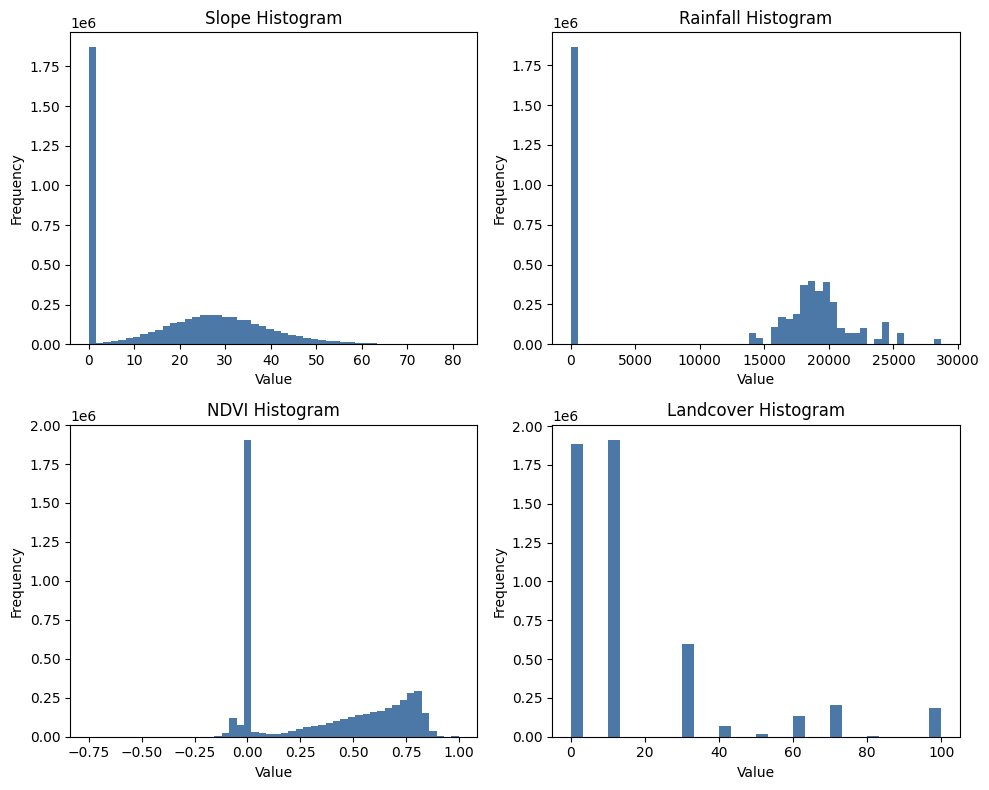

,class,count
1,10,1912216
0,0,1887107
2,30,598039
6,70,202279
8,100,186604
5,60,132190
3,40,70450
4,50,16099
7,80,7287


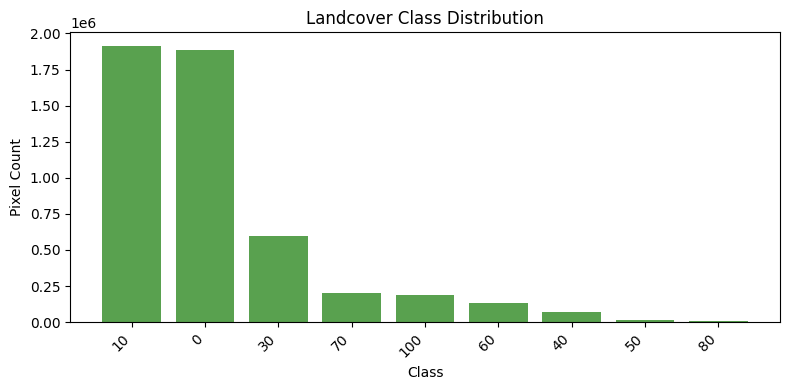

In [12]:
# QA stats + plots for key predictors
def raster_stats(path: Path) -> Dict:
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        nodata = int(np.ma.count_masked(data))
        flat = data.compressed()
        return {
            "min": float(np.min(flat)) if flat.size else np.nan,
            "max": float(np.max(flat)) if flat.size else np.nan,
            "mean": float(np.mean(flat)) if flat.size else np.nan,
            "missing": nodata,
            "count": int(flat.size),
        }

def plot_hist(path: Path, title: str, bins: int = 50):
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        flat = data.compressed()
    plt.hist(flat, bins=bins, color="#4C78A8")
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

# Paths for QA
qa_paths = {
    "slope": aligned_rasters["slope"],
    "ndvi": aligned_rasters["ndvi"],
    "rainfall": aligned_rasters["rainfall"],
    "landcover": aligned_rasters["landcover"],
}

# Print summary stats
for name, path in qa_paths.items():
    stats = raster_stats(path)
    print(name, stats)

# Histograms
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plot_hist(qa_paths["slope"], "Slope Histogram")
plt.subplot(2, 2, 2)
plot_hist(qa_paths["rainfall"], "Rainfall Histogram")
plt.subplot(2, 2, 3)
plot_hist(qa_paths["ndvi"], "NDVI Histogram")
plt.subplot(2, 2, 4)
plot_hist(qa_paths["landcover"], "Landcover Histogram", bins=30)
plt.tight_layout()
plt.show()

# Landcover class distribution
with rasterio.open(qa_paths["landcover"]) as src:
    lc = src.read(1, masked=True).compressed()
# Ensure integer dtype for class counts (avoid Pylance type ambiguity)
lc = np.asarray(lc, dtype="int32")
classes, counts = np.unique(lc, return_counts=True)
lc_df = pd.DataFrame({"class": classes, "count": counts}).sort_values("count", ascending=False)
display(lc_df.head(20))

plt.figure(figsize=(8, 4))
plt.bar(lc_df["class"].astype(str), lc_df["count"], color="#59A14F")
plt.title("Landcover Class Distribution")
plt.xlabel("Class")
plt.ylabel("Pixel Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## QA Visualization (Alignment + Clipping + Distance)
**Why this matters:** Visual QA catches alignment mismatches and clipping errors early, before they cause bad ML training data.

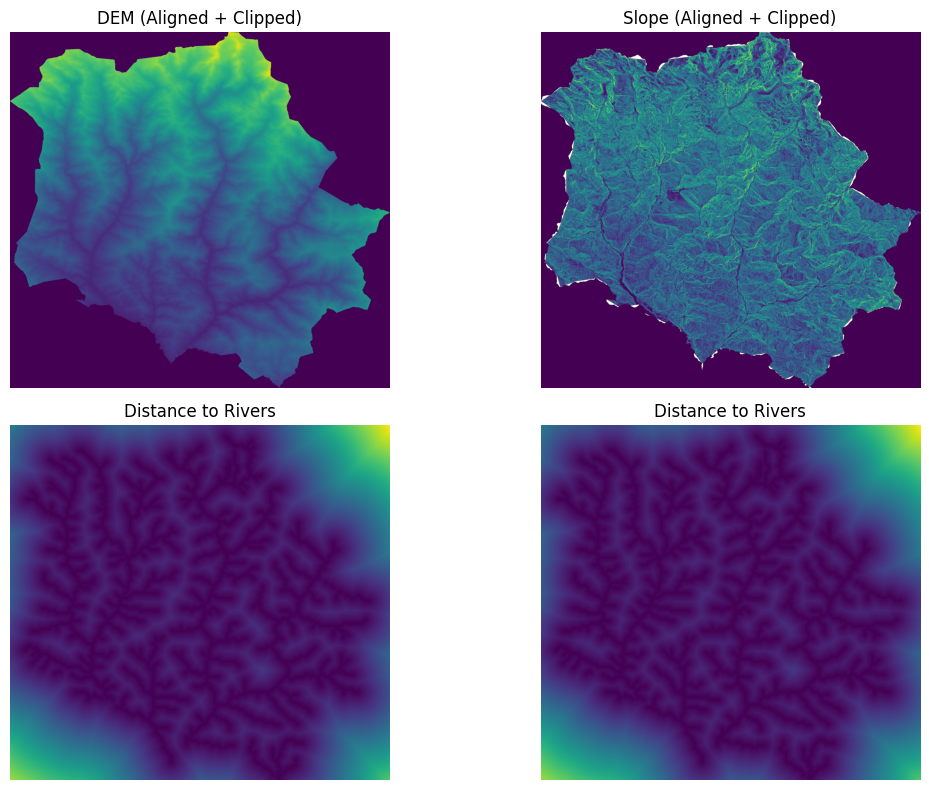

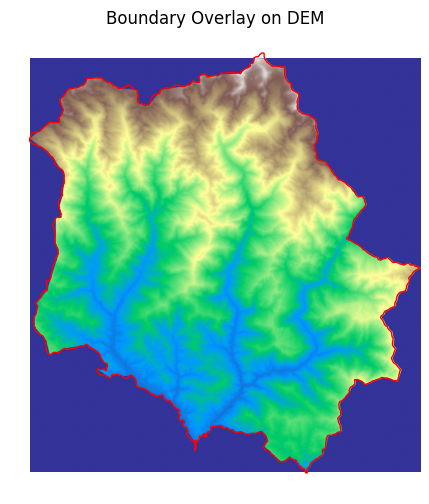

In [13]:
# Quick visual checks for alignment, clipping, and distance rasters
from typing import Optional

def plot_raster(path: Optional[Path], title: str):
    if path is None or not path.exists():
        plt.text(0.5, 0.5, f"Missing: {title}", ha="center")
        plt.title(title)
        plt.axis("off")
        return
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
    plt.imshow(data, cmap="viridis")
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plot_raster(aligned_rasters.get("dem"), "DEM (Aligned + Clipped)")
plt.subplot(2, 2, 2)
plot_raster(aligned_rasters.get("slope"), "Slope (Aligned + Clipped)")
plt.subplot(2, 2, 3)
if road_distance_path is not None:
    plot_raster(road_distance_path, "Distance to Roads")
else:
    plot_raster(river_distance_path, "Distance to Rivers")
plt.subplot(2, 2, 4)
plot_raster(river_distance_path, "Distance to Rivers")
plt.tight_layout()
plt.show()

# Boundary overlay check on DEM
with rasterio.open(aligned_rasters.get("dem")) as src:
    dem = src.read(1, masked=True)
    extent = (
        float(src.bounds.left),
        float(src.bounds.right),
        float(src.bounds.bottom),
        float(src.bounds.top),
    )

plt.figure(figsize=(6, 6))
plt.imshow(dem, extent=extent, cmap="terrain")
boundary_gdf.boundary.plot(ax=plt.gca(), color="red", linewidth=1)
plt.title("Boundary Overlay on DEM")
plt.axis("off")
plt.show()

## Steps 5–8: Stack → Inventory → Feature Extraction → ML Table
**Why this matters (science):** Stacking merges all aligned layers into one feature space. Landslide points provide positive labels, and random non-landslide points provide negatives. Sampling raster values at these locations creates the tabular dataset used for supervised learning.

In [14]:
# --- Step 5: Stack aligned rasters ---
feature_band_names = ["slope", "aspect", "twi", "rainfall", "ndvi", "landcover", "river_proximity"]
aligned_feature_paths = [
    aligned_rasters["slope"],
    aligned_rasters["aspect"],
    aligned_rasters["twi"],
    aligned_rasters["rainfall"],
    aligned_rasters["ndvi"],
    aligned_rasters["landcover"],
    river_distance_path,
 ]

# If road distance is available, include it
if road_distance_path is not None:
    feature_band_names.insert(-1, "road_distance")
    aligned_feature_paths.insert(-1, road_distance_path)

stack_path = PROCESSED_RASTER_DIR / "stack" / "feature_stack.tif"
stack_path = stack_rasters(aligned_feature_paths, stack_path)
print_raster_info(stack_path, "feature_stack")

# --- Step 6: Landslide inventory preprocessing ---
# Update column names to match your CSV if needed
LAT_COL = "latitude"
LON_COL = "longitude"

inventory_df = pd.read_csv(inventory_path)
inventory_df = inventory_df.dropna(subset=[LAT_COL, LON_COL]).copy()
inventory_gdf = gpd.GeoDataFrame(
    inventory_df,
    geometry=gpd.points_from_xy(inventory_df[LON_COL], inventory_df[LAT_COL]),
    crs=TARGET_CRS,
 )
inventory_gdf = gpd.clip(inventory_gdf, boundary_gdf)
inventory_out = PROCESSED_INVENTORY_DIR / "landslides_epsg4326.geojson"
inventory_gdf.to_file(inventory_out, driver="GeoJSON")
print_vector_info(inventory_out, "landslide_inventory")

# --- Step 7: Create non-landslide samples ---
n_positive = len(inventory_gdf)
neg_multiplier = 3
n_negative = n_positive * neg_multiplier
non_landslide_gdf = generate_random_points(boundary_gdf, n_negative, seed=42)
non_landslide_gdf["label"] = 0
inventory_gdf = inventory_gdf.copy()
inventory_gdf["label"] = 1

samples_gdf = pd.concat([inventory_gdf, non_landslide_gdf], ignore_index=True)
samples_gdf = gpd.GeoDataFrame(samples_gdf, geometry="geometry", crs=TARGET_CRS)

# --- Step 8: Extract raster values at sample points ---
features_df = extract_stack_values(stack_path, samples_gdf, feature_band_names)
features_df["landslide"] = samples_gdf["label"].values

# Remove rows with missing values
features_df = features_df.replace([np.inf, -np.inf], np.nan).dropna()
features_df = features_df.drop_duplicates()

training_csv_path = OUTPUTS_DIR / "training_dataset.csv"
features_df.to_csv(training_csv_path, index=False)
print("Saved training dataset:", training_csv_path)
features_df.head()

{'label': 'feature_stack', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\rasters\\stack\\feature_stack.tif', 'exists': True, 'crs': 'EPSG:4326', 'resolution': (0.0002694945852358564, 0.0002694945852358564), 'shape': (2167, 2313), 'bounds': BoundingBox(left=85.44178677419069, bottom=27.61201014065843, right=86.06512774984122, top=28.19600490686453), 'nodata': None, 'nodata_count': 0, 'nan_count': 28050}
{'label': 'landslide_inventory', 'path': 'D:\\Side_Projects\\ai-ml\\GeoShield_Ecothon\\data\\processed\\inventory\\landslides_epsg4326.geojson', 'exists': True, 'crs': 'EPSG:4326', 'features': 1433, 'bounds': [85.4596363823208, 27.634412007574408, 86.027256820397, 28.125090603349925]}
Saved training dataset: D:\Side_Projects\ai-ml\GeoShield_Ecothon\data\outputs\training_dataset.csv


,slope,aspect,twi,rainfall,ndvi,landcover,river_proximity,landslide
0,31.998774,190.111115,14.950398,18771.488281,0.730903,10.0,0.019467,1
1,51.425369,262.581940,14.444468,20435.472656,0.591532,10.0,0.018872,1
2,42.607269,252.590866,14.717822,20435.472656,0.773683,10.0,0.017795,1
3,31.089102,256.018005,14.959852,20435.472656,0.445132,30.0,0.012303,1
4,34.210606,246.123184,14.859812,20435.472656,0.334151,30.0,0.012202,1


## Steps 9–14: Random Forest → Metrics → Feature Importance → Susceptibility Map
**Why this matters (science):** Random Forest learns nonlinear relationships between terrain factors and landslide occurrence. The trained model estimates probability of landslide susceptibility for every pixel, producing the final risk surface.

Accuracy: 0.8362676056338029
              precision    recall  f1-score   support

           0      0.859     0.934     0.895       850
           1      0.736     0.545     0.627       286

    accuracy                          0.836      1136
   macro avg      0.798     0.740     0.761      1136
weighted avg      0.828     0.836     0.828      1136



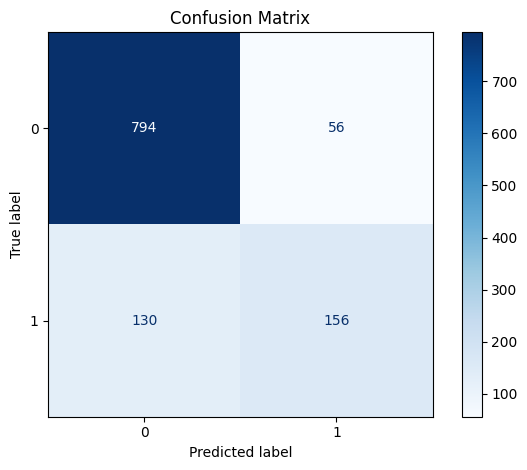

Saved model: D:\Side_Projects\ai-ml\GeoShield_Ecothon\models\random_forest.pkl


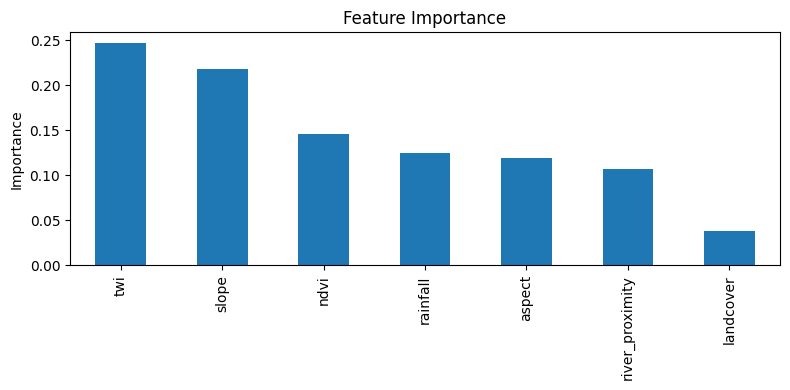

Saved feature importance figure: D:\Side_Projects\ai-ml\GeoShield_Ecothon\data\outputs\figures\feature_importance.png
Saved susceptibility raster: D:\Side_Projects\ai-ml\GeoShield_Ecothon\data\outputs\susceptibility_map.tif


In [15]:
# --- Step 9-12: Train Random Forest and evaluate ---
X = features_df[feature_band_names]
y = features_df["landslide"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
 )
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Save trained model (ensure target folder exists)
model_path = PROJECT_ROOT / "models" / "random_forest.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_model, model_path)
print("Saved model:", model_path)

# --- Step 13: Feature importance visualization ---
importances = pd.Series(rf_model.feature_importances_, index=feature_band_names).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
fig_path = OUTPUT_FIG_DIR / "feature_importance.png"
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved feature importance figure:", fig_path)

# --- Step 14: Susceptibility prediction raster ---
susceptibility_path = OUTPUTS_DIR / "susceptibility_map.tif"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

with rasterio.open(stack_path) as src:
    profile = src.profile.copy()
    profile.update({"count": 1, "dtype": "float32", "nodata": None})
    with rasterio.open(susceptibility_path, "w", **profile) as dst:
        for _, window in src.block_windows(1):
            data = src.read(window=window)  # shape: (bands, rows, cols)
            bands, rows, cols = data.shape
            data_2d = data.reshape(bands, -1).T
            # Replace nodata with NaN and drop for prediction
            data_2d = np.where(np.isfinite(data_2d), data_2d, np.nan)
            valid_mask = ~np.isnan(data_2d).any(axis=1)
            preds = np.zeros(data_2d.shape[0], dtype="float32")
            feature_columns = feature_band_names
            if valid_mask.any():
                chunk_df = pd.DataFrame(data_2d[valid_mask], columns=feature_columns)
                preds[valid_mask] = rf_model.predict_proba(chunk_df)[:, 1].astype("float32")
            preds = preds.reshape(rows, cols)
            dst.write(preds, 1, window=window)

print("Saved susceptibility raster:", susceptibility_path)

## Workflow Diagram and Web Map Integration
**Pipeline diagram (high level):**
```mermaid
graph TD
  A[Raw Rasters + Vectors + Inventory] --> B[Reproject to EPSG:4326]
  B --> C[Clip to District Boundary]
  C --> D[Align to DEM Grid]
  D --> E[Distance Rasters for Roads/Rivers]
  E --> F[Stack Feature Rasters]
  F --> G[Sample Points + Extract Features]
  G --> H[Train Random Forest]
  H --> I[Predict Susceptibility Raster]
  I --> J[Visualize + Deploy]
```

**Leaflet/Folium integration (simple):**
1) Convert `susceptibility_map.tif` to web tiles (EPSG:3857).
2) Serve tiles locally or export for a web dashboard.

Example using `localtileserver` (quick demo):
```python
from localtileserver import TileClient, get_leaflet_tile_layer
import folium

client = TileClient(r"D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/outputs/susceptibility_map.tif")
layer = get_leaflet_tile_layer(client)

m = folium.Map(location=[27.8, 85.8], zoom_start=9)
layer.add_to(m)
folium.LayerControl().add_to(m)

m.save(r"D:/Side_Projects/ai-ml/GeoShield_Ecothon/backend/data/outputs/susceptibility_map.html")
```

**Output files (expected, all under backend/):**
- `backend/data/processed/rasters/aligned/*_aligned.tif`
- `backend/data/processed/rasters/aligned/road_distance.tif`
- `backend/data/processed/rasters/aligned/river_distance.tif`
- `backend/data/outputs/training_dataset.csv`
- `backend/models/random_forest.pkl`
- `backend/data/outputs/susceptibility_map.tif`
- `backend/data/outputs/figures/feature_importance.png`


## Demo Dashboard (Leaflet + Flask)
Run the lightweight dashboard once the susceptibility raster is generated:

```
python app/dashboard_app.py
```

Then open http://localhost:5000 in your browser.

## Leaflet/Folium App Scaffold (Minimal Demo)
A ready-to-run script has been created at `app/leaflet_demo.py`. It loads the susceptibility raster and optional landslide points, then saves an HTML map.

**Run from terminal:**
```
python app/leaflet_demo.py
```

It will output:
- `data/outputs/susceptibility_map.html`
